<a href="https://colab.research.google.com/github/Likhithaa-Guntaka/ai-skills-market-intelligence/blob/main/notebooks/04_final_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Title:** Tracking the AI Skills Revolution: How Demand for AI & Data Skills Is Changing

*The original Phase 1 title carried the scope "(2022–Present)". That scope turned out not to be achievable: the Adzuna `/search` endpoint returns only currently-listed job postings, so postings going back to 2022 cannot be retrieved through it. The analysis below covers the recent window the API actually returns — see the monthly chart for the observed range.*

by Likhitha Guntaka


## **Project objective:** To analyze demand for AI and Data-related skills in **US** job postings, using two live data sources: the Adzuna Jobs API (US endpoint) and the Stack Overflow tags API.

*The two sources are described side by side; they are not merged into a single dataset in this analysis.*

## Data overview

| | Adzuna Jobs API | Stack Overflow (Stack Exchange) tags API |
|---|---|---|
| Endpoint | `/v1/api/jobs/us/search/{page}` — **US only** | `/2.3/tags` (`site=stackoverflow`, `sort=popular`) |
| Query | `"AI OR Data OR Machine Learning"`, 3 paginated pages | top 100 tags by all-time question volume |
| Observations | see the `Total jobs pulled` / `Rows:` output below | 100 tags |
| Time coverage | currently-listed postings only; see the monthly chart for the observed date range | all-time cumulative counts, **no date dimension** |
| Fields used | title, company, location, salary_min, salary_max, category, created, description | tag_name, question_count, has_synonyms |

### Original research questions vs. what the data allowed

| Phase 1 question | Status in this analysis |
|---|---|
| Growth in AI/data job demand | **Partly.** Postings are counted per month, but only across the short recent window the API returns, which cannot measure growth since 2022. |
| Salary differences between AI and non-AI technical roles | **Not possible.** The query retrieves only AI/Data postings, so there is no non-AI comparison group. |
| Skill keywords linked to demand and compensation | **Demand only, and weakly.** Keyword counts run against descriptions Adzuna truncates to ~500 characters. No keyword-to-salary analysis was performed. |
| Geographic hiring patterns | **Attempted, not conclusive.** Locations resolve to granular Adzuna locality names carrying very few postings each. |
| Developer interest in emerging AI technologies | **Not analyzed.** The tags endpoint returns all-time popular tags — general-purpose languages — and carries no dates. |
| Relationship between developer activity and employer demand | **Not demonstrated.** The two datasets are never joined and no statistical comparison is performed. |

## D1. Library imports

In [1]:
# Used to send requests to online APIs
import requests

# Used to store and manipulate data in tables (DataFrames)
import pandas as pd

# Used for numerical operations (like handling missing values)
import numpy as np

# Used to work with dates and timestamps
from datetime import datetime

# Used to create charts and plots
import matplotlib.pyplot as plt

##D2. Data pre-processing

### AP1-1: Adzuna (Jobs API)
**Connecting to Adzuna Jobs API**
* This API provides real job postings related to AI, Data, and Technology.
* The request uses the Adzuna **US** endpoint (`/jobs/us/`), so this is **US job posting data**, not global data.
* A city filter can be switched ON to narrow results to a single US location (for example New York or San Francisco). It is left OFF here, so results cover the US as a whole.


In [2]:
# CITY FILTER SWITCH
# By default, this is set to GLOBAL (False)
# Change to True if you want to analyze a specific city
use_city_filter = False

# You can change this to: "New York", "London", "San Francisco", etc.
city_name = "New York"

# False = Global data
# True = City-specific data
# Only need to change ONE word to switch

In [3]:
# Connect to Adzuna API

# Credentials are loaded from Colab Secrets (sidebar -> Secrets / key icon).
# Add ADZUNA_APP_ID and ADZUNA_APP_KEY there and enable notebook access.
# Outside Colab, set them as environment variables of the same name.
import os

try:
    from google.colab import userdata
    APP_ID = userdata.get("ADZUNA_APP_ID")
    APP_KEY = userdata.get("ADZUNA_APP_KEY")
except ImportError:
    APP_ID = os.environ["ADZUNA_APP_ID"]
    APP_KEY = os.environ["ADZUNA_APP_KEY"]

# Using US Adzuna endpoint for job market analysis
adzuna_url = "https://api.adzuna.com/v1/api/jobs/us/search/1"

# Parameters for the request
params = {
    "app_id": APP_ID,
    "app_key": APP_KEY,
    "results_per_page": 100,
    "what": "AI OR Data OR Machine Learning"
}

# If the city filter is ON, add location to the query
if use_city_filter:
    params["where"] = city_name

# Header to avoid being blocked
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send request to Adzuna
response = requests.get(adzuna_url, params=params, headers=headers)

# Confirm request success
# Redact credentials before printing so they never land in saved notebook output
safe_url = response.url.replace(APP_ID, "<APP_ID>").replace(APP_KEY, "<APP_KEY>")
print("Final URL:", safe_url)
print("Status Code:", response.status_code)
print("Using city filter:", use_city_filter)
print("City:", city_name if use_city_filter else "GLOBAL")

Final URL: https://api.adzuna.com/v1/api/jobs/us/search/1?app_id=<APP_ID>&app_key=<APP_KEY>&results_per_page=100&what=AI+OR+Data+OR+Machine+Learning
Status Code: 200
Using city filter: False
City: GLOBAL


In [4]:
# Pagination: Pull multiple pages of results

all_jobs = []

# Loop through first 3 pages (you can increase later)
for page in range(1, 4):   # pages 1, 2, 3
    url = f"https://api.adzuna.com/v1/api/jobs/us/search/{page}"
    response = requests.get(url, params=params)

    # Convert each page to JSON
    data = response.json()

    # Add job results from this page to master list
    for job in data.get("results", []):
        all_jobs.append(job)

# Convert to DataFrame
print("Total jobs pulled:", len(all_jobs))

adzuna_df = pd.DataFrame(all_jobs)

# Show a few rows
adzuna_df.head()

Total jobs pulled: 150


,category,redirect_url,salary_min,adref,salary_max,longitude,company,location,salary_is_predicted,id,title,latitude,description,created,__CLASS__,contract_time,contract_type
0,"{'label': 'IT Jobs', '__CLASS__': 'Adzuna::API...",https://www.adzuna.com/land/ad/5797176961?se=A...,215766.47,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc5NzE3Njk2MSIsI...,215766.47,-77.097739,"{'display_name': 'Amazon', '__CLASS__': 'Adzun...",{'__CLASS__': 'Adzuna::API::Response::Location...,1,5797176961,"Delivery Consultant- AI/ML, Data & Machine Lea...",38.886306,Description The Amazon Web Services Profession...,2026-07-11T17:29:30Z,Adzuna::API::Response::Job,NaN,NaN
1,"{'label': 'IT Jobs', '__CLASS__': 'Adzuna::API...",https://www.adzuna.com/land/ad/5797176959?se=A...,202619.81,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc5NzE3Njk1OSIsI...,202619.81,-77.097739,"{'display_name': 'Amazon', '__CLASS__': 'Adzun...",{'__CLASS__': 'Adzuna::API::Response::Location...,1,5797176959,"Delivery Consultant- AI/ML, Data & Machine Lea...",38.886306,Description The Amazon Web Services Profession...,2026-07-11T17:29:20Z,Adzuna::API::Response::Job,NaN,NaN
2,"{'label': 'IT Jobs', '__CLASS__': 'Adzuna::API...",https://www.adzuna.com/land/ad/5797251988?se=A...,202536.94,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc5NzI1MTk4OCIsI...,202536.94,-77.097739,{'__CLASS__': 'Adzuna::API::Response::Company'...,{'__CLASS__': 'Adzuna::API::Response::Location...,1,5797251988,"Delivery Consultant- AI/ML, Data & Machine Lea...",38.886306,Description The Amazon Web Services Profession...,2026-07-11T17:37:06Z,Adzuna::API::Response::Job,NaN,NaN
3,{'__CLASS__': 'Adzuna::API::Response::Category...,https://www.adzuna.com/land/ad/5845429289?se=A...,208765.95,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTg0NTQyOTI4OSIsI...,208765.95,-77.097739,"{'display_name': 'Amazon', '__CLASS__': 'Adzun...","{'display_name': 'State Farm, Arlington County...",1,5845429289,"Delivery Consultant- AI/ML, Data & Machine Lea...",38.886306,Description The Amazon Web Services Profession...,2026-08-17T16:52:59Z,Adzuna::API::Response::Job,NaN,NaN
4,"{'label': 'IT Jobs', '__CLASS__': 'Adzuna::API...",https://www.adzuna.com/land/ad/5867068467?se=A...,160465.33,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiQUhLcHk2dXI4UkdsW...,160465.33,-73.970368,"{'display_name': 'BNY', '__CLASS__': 'Adzuna::...","{'area': ['US', 'New York', 'New York City'], ...",1,5867068467,"Senior Director, AI / Machine Learning Data En...",40.767036,hackajob is collaborating with BNY to connect ...,2026-09-02T07:52:40Z,Adzuna::API::Response::Job,NaN,NaN


In [5]:
adzuna_df.shape

(150, 17)

#### Converting Adzuna data into a DataFrame

* Each row will represent one job posting.
* Each column will represent job details (title, salary, skills, etc.).

In [6]:
# Flatten the FULL paginated result set collected above.
# Iterate over all_jobs (every page), not response.json(), which holds only the
# final page of the pagination loop and would silently discard the earlier pages.

# Store jobs here
adzuna_jobs = []

# Loop through every job pulled across all pages
for job in all_jobs:
    adzuna_jobs.append({
        "title": job.get("title"),
        "company": job.get("company", {}).get("display_name"),
        "location": job.get("location", {}).get("display_name"),
        "salary_min": job.get("salary_min"),
        "salary_max": job.get("salary_max"),
        "category": job.get("category", {}).get("label"),
        "created": job.get("created"),
        "description": job.get("description")
    })

# Convert to DataFrame
adzuna_df = pd.DataFrame(adzuna_jobs)

# Show size of dataset
print("Rows:", adzuna_df.shape[0])
print("Columns:", adzuna_df.shape[1])

adzuna_df.head(21)

Rows: 150
Columns: 8


,title,company,location,salary_min,salary_max,category,created,description
0,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"State Farm, Arlington County",215766.47,215766.47,IT Jobs,2026-07-11T17:29:30Z,Description The Amazon Web Services Profession...
1,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"State Farm, Arlington County",202619.81,202619.81,IT Jobs,2026-07-11T17:29:20Z,Description The Amazon Web Services Profession...
2,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"State Farm, Arlington County",202536.94,202536.94,IT Jobs,2026-07-11T17:37:06Z,Description The Amazon Web Services Profession...
3,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"State Farm, Arlington County",208765.95,208765.95,IT Jobs,2026-08-17T16:52:59Z,Description The Amazon Web Services Profession...
4,"Senior Director, AI / Machine Learning Data En...",BNY,"New York City, New York",160465.33,160465.33,IT Jobs,2026-09-02T07:52:40Z,hackajob is collaborating with BNY to connect ...
5,Data Scientist - Ai/machine Learning with Secu...,Markon,"Savage, Anne Arundel County",177234.48,177234.48,IT Jobs,2026-07-09T15:08:13Z,"PLEX Solutions, A Part of Markon, is looking f..."
6,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Herndon, Fairfax County",178415.83,178415.83,IT Jobs,2026-07-13T20:56:20Z,Description The Amazon Web Services Profession...
7,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Fort Myer, Arlington County",178606.33,178606.33,IT Jobs,2026-07-13T20:56:21Z,Description The Amazon Web Services Profession...
8,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Fort Myer, Arlington County",167851.06,167851.06,IT Jobs,2026-07-13T20:56:21Z,Description The Amazon Web Services Profession...
9,"Delivery Consultant- AI/ML, Data & Machine Lea...",Amazon,"Herndon, Fairfax County",167544.95,167544.95,IT Jobs,2026-07-13T20:56:20Z,Description The Amazon Web Services Profession...


#### Cleaning and formatting Adzuna data
In this step, Data is prepared the for analysis by:
- Cleaning column names
- Fixing date format
- Handling missing salary values

In [7]:
# Standardize column names
adzuna_df.columns = [col.lower().strip().replace(" ", "_") for col in adzuna_df.columns]

# Convert created date
adzuna_df["created"] = pd.to_datetime(adzuna_df["created"], errors="coerce")

# Handle missing salary values
adzuna_df["salary_min"] = adzuna_df["salary_min"].fillna(0)
adzuna_df["salary_max"] = adzuna_df["salary_max"].fillna(0)

# Check if any nulls remain
adzuna_df.isnull().sum()

,0
title,0
company,1
location,0
salary_min,0
salary_max,0
category,0
created,0
description,0


#### Creating an AI keyword indicator

This column checks if the job description contains important AI-related skills.

In [8]:
import re

# Multi-word and unambiguous terms are safe as plain substring matches.
keywords = [
    "artificial intelligence",
    "machine learning",
    "deep learning",
    "data scientist",
    "llm",
    "python",
    "neural network"
]

# "ai" and "ml" are short enough to appear inside unrelated words such as
# "available", "training", "maintain", "email", "html" and "xml", so they are
# matched as standalone terms only. Word boundaries still allow the forms that
# matter: "AI/ML", "AI-powered", "generative AI", "ml-ops", "ML pipelines".
short_terms = re.compile(r"\b(?:ai|ml)\b")

adzuna_df["contains_ai_keywords"] = adzuna_df["description"].str.lower().apply(
    lambda x: (any(word in x for word in keywords) or bool(short_terms.search(x)))
    if isinstance(x, str) else False
)

# Show 10 random rows as sample
adzuna_df.sample(21)[["title", "location", "contains_ai_keywords"]]

,title,location,contains_ai_keywords
137,Senior Data Engineer-PBM,"Woonsocket, Providence County",True
3,"Delivery Consultant- AI/ML, Data & Machine Lea...","State Farm, Arlington County",True
74,Agentic AI Engineer,"Edison, Middlesex County",True
118,Data Scientist,"Chantilly, Fairfax County",True
75,Agentic AI Engineer,"Atlanta, Fulton County",True
45,AI Data Engineer,"Fort Belvoir, Fairfax County",True
92,Quality Assurance Technician 2nd Shift,"New Jersey, US",False
108,Sr AI Engineer,US,True
73,Subject Matter Expert (Cleared – AI/ML | Data ...,"Wpafb, Greene County",False
51,Senior Software Engineer: AI,"Ny State Campus, Albany County",True


In [9]:
print("Percentage of jobs mentioning AI-related keywords:",
      (adzuna_df["contains_ai_keywords"].sum() / len(adzuna_df)) * 100, "%")

Percentage of jobs mentioning AI-related keywords: 82.0 %


### API-2: Connecting to StackExchange (Stack Overflow) API
This API provides data on developer activity by showing
the most popular technology and programming tags.


In [10]:
# This is the main URL for the Stack Exchange / Stack Overflow API
# It allows us to access data about developer questions & tags
so_url = "https://api.stackexchange.com/2.3/tags"


# These are the parameters we send to the API
params = {

    # "desc" means we want results in descending (highest → lowest) order
    "order": "desc",

    # "popular" means return the most popular tags based on activity
    "sort": "popular",

    # We specifically want data from the Stack Overflow website
    "site": "stackoverflow",

    # This limits the response to the top 100 tags
    "pagesize": 100
}


# Send a GET request to the API using the URL and parameters
so_response = requests.get(so_url, params=params)


# Print the status code to confirm successful connection
# 200 = Success
print("Status Code:", so_response.status_code)


# Convert the raw API response into JSON format (a Python-readable dictionary)
so_data = so_response.json()


# Print the number of tags that were pulled from the API
print("Number of tags pulled:", len(so_data["items"]))

Status Code: 200
Number of tags pulled: 100


#### Converting Stack Overflow data into a DataFrame

In [11]:
# Create an empty list to store the tag data
tags = []


# Loop through each item (each technology / skill tag)
for item in so_data["items"]:

    # Add the required information for each tag into the list
    tags.append({
        "tag_name": item.get("name"),               # Name of the technology / skill
        "question_count": item.get("count"),        # Number of questions related to this tag
        "has_synonyms": item.get("has_synonyms")    # Whether the tag has similar versions
    })


# Convert the list of dictionaries into a pandas DataFrame (table)
stackoverflow_df = pd.DataFrame(tags)


# Print how many rows and columns the DataFrame has
print("Rows:", stackoverflow_df.shape[0])
print("Columns:", stackoverflow_df.shape[1])


# Display the rows of the DataFrame
stackoverflow_df.head(21)

Rows: 100
Columns: 3


,tag_name,question_count,has_synonyms
0,.net,340237,True
1,ajax,220324,True
2,algorithm,121430,True
3,amazon-web-services,158630,True
4,android,1413874,True
5,android-studio,90157,True
6,angular,306395,True
7,angularjs,261236,True
8,apache,91471,True
9,apache-spark,82510,True


#### Cleaning Stack Overflow data

In [12]:
# Convert question_count to numeric (just in case it was read as text)
stackoverflow_df["question_count"] = pd.to_numeric(
    stackoverflow_df["question_count"],
    errors="coerce"   # If there are bad values, turn them into NaN
)


# Check if there are any missing (null) values in the dataset
stackoverflow_df.isnull().sum()


# Show the top 10 most popular technology skills
# (The ones with the highest question_count appear first)
stackoverflow_df.sort_values(by="question_count", ascending=False).head(21)

,tag_name,question_count,has_synonyms
43,javascript,2521822,True
67,python,2204681,True
42,java,1914472,True
17,c#,1621768,True
64,php,1461062,True
4,android,1413874,True
38,html,1185146,True
44,jquery,1029947,True
18,c++,814062,True
19,css,805631,True


In [13]:
# Clean datetime and remove timezone warnings
adzuna_df["created"] = (
    pd.to_datetime(adzuna_df["created"], errors="coerce")
    .dt.tz_localize(None)
)

# Prepare month cleanly without warnings
# Lower-bound guard only. Adzuna returns currently-listed postings, so in
# practice this drops nothing; it is not evidence of coverage back to 2022.
filtered_df = adzuna_df[adzuna_df["created"] >= "2022-01-01"]
filtered_df["month"] = filtered_df["created"].dt.to_period("M").dt.to_timestamp()

In [14]:
# Theme Colors
terracotta = "#E2725B"
old_burgundy = "#43302E"
sky_blue = "#87CEEB"
dark_green = "#013220"

## D3. Data analysis


### Question 1: How has the number of AI/Data job postings changed over time?

#### Answer

In [15]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool, Span, Label
from bokeh.io import output_notebook
output_notebook()

import pandas as pd

# COLOR PALETTE
burnt_sienna   = "#D95D39"
deep_merlot    = "#4B1D2A"
vintage_gold   = "#C49F48"
soft_sandstone = "#F6E6CC"
evening_teal   = "#184E77"

# Convert and filter dates
adzuna_df["created"] = pd.to_datetime(adzuna_df["created"], errors="coerce")
# Lower-bound guard only. Adzuna returns currently-listed postings, so in
# practice this drops nothing; it is not evidence of coverage back to 2022.
filtered_df = adzuna_df[adzuna_df["created"] >= "2022-01-01"]

# Group by month
filtered_df["month"] = filtered_df["created"].dt.to_period("M").dt.to_timestamp()
monthly_counts = filtered_df.groupby("month").size().reset_index(name="count")

# 3-month moving average
monthly_counts["ma3"] = monthly_counts["count"].rolling(3).mean()

source = ColumnDataSource(monthly_counts)

# FIGURE
p = figure(
    x_axis_type='datetime',
    width=950,
    height=480,
    title="Monthly AI/Data Job Postings (Observed Window)",
    background_fill_color="#ffffff"
)

# Soft sandstone area shading
p.varea(
    x="month",
    y1=0,
    y2="count",
    fill_color=soft_sandstone,
    fill_alpha=0.45,
    source=source
)

# Main line in burnt sienna
p.line(
    x="month",
    y="count",
    line_width=3,
    color=burnt_sienna,
    legend_label="Monthly Job Postings",
    source=source
)

# Merlot markers
p.circle(
    x="month",
    y="count",
    size=8,
    fill_color=burnt_sienna,
    color=deep_merlot,
    line_width=2,
    source=source
)

# Moving average in evening teal
p.line(
    x="month",
    y="ma3",
    color=evening_teal,
    line_width=3,
    line_dash="dashed",
    legend_label="3-Month Moving Avg",
    source=source
)

# PEAK ANNOTATION (Vintage Gold)
peak_row = monthly_counts.loc[monthly_counts["count"].idxmax()]
peak_date = peak_row["month"]
peak_val  = peak_row["count"]

peak = Span(location=peak_val, dimension="width",
            line_color=vintage_gold, line_width=2, line_dash="dotted")
p.add_layout(peak)

peak_label = Label(
    x=peak_date,
    y=peak_val + 2,
    text=f"Peak: {peak_date.strftime('%Y-%m')} ({peak_val})",
    text_color=vintage_gold,
    text_font_size="12pt",
    text_font_style="bold"
)
p.add_layout(peak_label)

# INTERACTIVE HOVER TOOL
hover = HoverTool(
    tooltips=[
        ("Month", "@month{%Y-%m}"),
        ("Postings", "@count"),
        ("3-Month Avg", "@ma3{0.0}")
    ],
    formatters={'@month': 'datetime'},
    mode='vline'
)
p.add_tools(hover)

# STYLE
p.xaxis.axis_label = "Month"
p.yaxis.axis_label = "Number of AI-Related Job Postings"
p.xaxis.major_label_orientation = 0.7

p.title.text_font_size = "18pt"
p.title.text_color = deep_merlot
p.legend.label_text_color = deep_merlot

p.grid.grid_line_alpha = 0.25

show(p)

### Question 2: Which AI/Data skills appear most often in job descriptions?

#### Answer

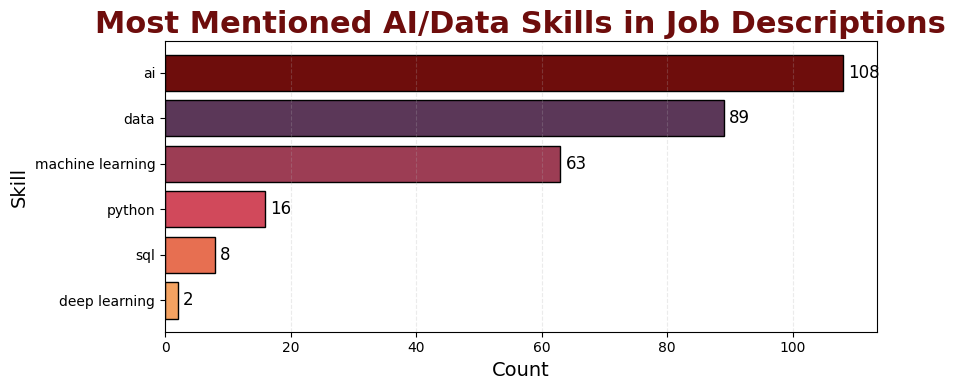

In [16]:
# Extract and count keywords
keywords = ["python", "machine learning", "ai", "data", "deep learning", "sql"]

# "ai" is counted as a standalone term so it does not fire inside "available",
# "training" or "maintain". Every other keyword keeps plain substring matching.
patterns = {"ai": r"\bai\b"}

skill_counts = {}
for word in keywords:
    skill_counts[word] = adzuna_df['description'].str.lower().str.contains(patterns.get(word, word)).sum()

skills_df = pd.DataFrame.from_dict(skill_counts, orient='index', columns=['count'])
skills_df = skills_df.sort_values('count')

# Custom aesthetic gradient
colors = ["#F4A261", "#E76F51", "#D1495B", "#9C3D54", "#5B3758"]
# Cycle the palette so there is always one colour per skill. Slicing alone left
# the list shorter than skills_df and raised IndexError when skills tied for top.
colors = (colors * 2)[:len(skills_df)]

highlight_color = "#6E0D0C"  # burgundy

# Highlight top skill
top_skill = skills_df['count'].idxmax()

bar_colors = [
    highlight_color if skill == top_skill else colors[i]
    for i, skill in enumerate(skills_df.index)
]

# Plot
plt.figure(figsize=(9, 4))
bars = plt.barh(
    skills_df.index,
    skills_df['count'],
    color=bar_colors,
    edgecolor="black",
    linewidth=1
)

# Add count labels
for bar in bars:
    value = bar.get_width()
    plt.text(value + 0.8, bar.get_y() + bar.get_height()/2,
             f"{int(value)}", va='center', fontsize=12)

plt.title(
    "Most Mentioned AI/Data Skills in Job Descriptions",
    fontsize=22, fontweight="bold", color="#6E0D0C"
)

plt.xlabel("Count", fontsize=14)
plt.ylabel("Skill", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()

### Question 3: What are the top 10 most popular developer skills on StackOverflow?

#### Answer

In [17]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook
output_notebook()

# Prepare data
top10 = stackoverflow_df.sort_values("question_count", ascending=False).head(10)

colors = [
    "#D72638", "#F49D37", "#1B998B", "#2E294E", "#9C27B0",
    "#E91E63", "#2196F3", "#4CAF50", "#FF6F61", "#6A4C93"
]

top10["color"] = colors[:len(top10)]
top10["has_synonyms_str"] = top10["has_synonyms"].apply(lambda x: "Yes" if x else "No")

source = ColumnDataSource(top10)

p = figure(
    x_range=list(top10["tag_name"]),
    width=900,
    height=450,
    title="Top 10 Most Popular Developer Tags on StackOverflow",
    toolbar_location="right",
    tools="pan,wheel_zoom,box_zoom,reset"
)

p.vbar(
    x="tag_name",
    top="question_count",
    width=0.6,
    fill_color="color",
    line_color="white",
    line_width=1.5,
    source=source
)

p.add_tools(HoverTool(tooltips=[
    ("Tag", "@tag_name"),
    ("Questions", "@question_count{0,0}"),
    ("Has Synonyms?", "@has_synonyms_str")
]))

# Styling
p.xaxis.major_label_orientation = 1.0
p.yaxis.axis_label = "Number of Questions"
p.xaxis.axis_label = "Tag Name"
p.title.text_font_size = "19pt"
p.title.text_color = "#4A0E0E"  # deep burgundy
p.grid.grid_line_alpha = 0.2
p.background_fill_color = "#FCFCFF"

show(p)

### Question 4: What is the salary distribution for AI/Data roles?

#### Answer

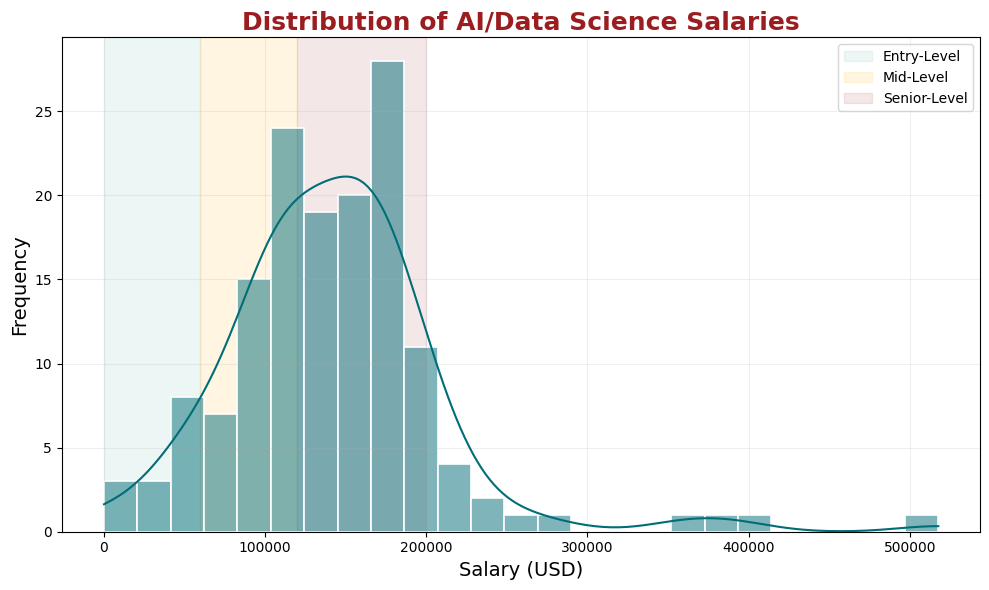

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate average salary for each posting (re-added to ensure it's always present)
adzuna_df['salary_avg'] = (adzuna_df['salary_min'] + adzuna_df['salary_max']) / 2

# Missing salaries were filled with 0 during cleaning. Exclude non-positive
# values so they are not plotted as real compensation (matches Phase III).
valid_salaries = adzuna_df[adzuna_df["salary_avg"] > 0]["salary_avg"]

rich_ruby = "#9B1D20"
amber_gold = "#FFB100"
deep_teal = "#006D77"
soft_mint = "#83C5BE"
royal_purple = "#6A4C93"
sand_beige = "#F4E9CD"

plt.figure(figsize=(10,6))

# Shaded salary ranges
plt.axvspan(0, 60000, color=soft_mint, alpha=0.15, label="Entry-Level")
plt.axvspan(60000, 120000, color=amber_gold, alpha=0.12, label="Mid-Level")
plt.axvspan(120000, 200000, color=rich_ruby, alpha=0.10, label="Senior-Level")

# Histogram
sns.histplot(
    valid_salaries,
    bins=25,
    kde=True,
    color=deep_teal,
    edgecolor="white",
    linewidth=1.2
)

plt.title("Distribution of AI/Data Science Salaries", fontsize=18, color=rich_ruby, fontweight="bold")
plt.xlabel("Salary (USD)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(alpha=0.2)

plt.legend()
plt.tight_layout()
plt.show()

### Question 5: Which cities show the highest concentration of AI jobs?

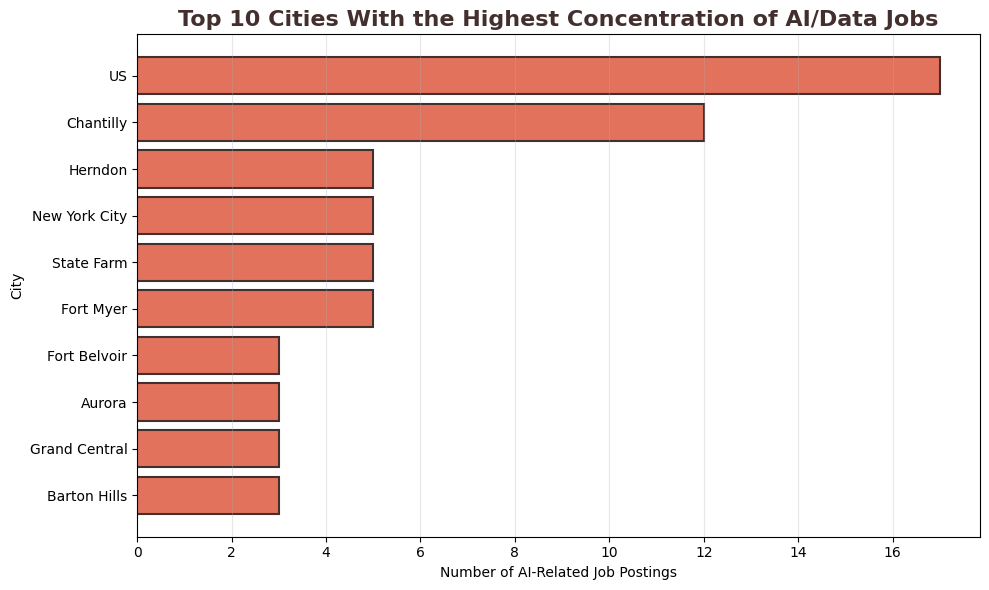

In [19]:
import matplotlib.pyplot as plt

# Clean location data
# Some rows may have missing location — drop them
adzuna_df['location'] = adzuna_df['location'].fillna("Unknown")

# Extract city name (usually the FIRST part before comma)
adzuna_df['city'] = adzuna_df['location'].astype(str).apply(lambda x: x.split(",")[0])

# Count jobs per city
city_counts = adzuna_df['city'].value_counts().head(10)   # Top 10 cities

plt.figure(figsize=(10,6))

plt.barh(
    city_counts.index[::-1],
    city_counts.values[::-1],
    color=terracotta,
    edgecolor=old_burgundy,
    linewidth=1.5
)

plt.title("Top 10 Cities With the Highest Concentration of AI/Data Jobs",
          fontsize=16, fontweight='bold', color=old_burgundy)

plt.xlabel("Number of AI-Related Job Postings")
plt.ylabel("City")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##D4. Summary of key findings

*Scope note: these findings describe the sample the Adzuna US endpoint and the Stack Overflow tags API actually returned. The sample is small and covers only the recent window Adzuna exposes, so the results below are descriptive. Every numeric value must be read from the regenerated charts above after re-running the notebook.*

* **Posting volume varies from month to month.** Adzuna returns only currently-listed postings, so older months are systematically under-represented and recent months are fuller. The month-to-month shape therefore reflects listing recency as much as hiring activity. It is not evidence of a hiring cycle, an event-driven spike, or a long-term trend.
* **The 3-month moving average smooths the series but does not establish a trend.** With only a few monthly points available, a 3-period rolling mean yields too few windows to separate a trend from noise.
* **Only some of the searched keywords are detectable in the description text.** In the previous run, `data`, `ai` and `machine learning` were detected while `python`, `sql` and `deep learning` were detected zero times. Read the regenerated chart for the current counts rather than relying on that earlier result.
* **A zero count does not mean employers do not want the skill.** The Adzuna free tier truncates each description to roughly 500 characters — every record ends in "…" — and the surviving text is usually company boilerplate rather than the requirements section, where specific tool names normally appear. This measures the opening of a posting, not its requirements.
* **Keyword matching is unanchored substring matching.** `str.contains("ai")` also matches words such as "available", "training" and "maintain", so the `ai` count should be read as an upper bound rather than a precise figure.
* **Stack Overflow tag counts are all-time cumulative totals with no date attached.** They describe accumulated question volume for general-purpose languages, and cannot show change over time or interest in emerging AI tools.
* **This analysis does not demonstrate a relationship between developer activity and employer demand.** The two datasets are never joined and no statistical comparison is performed. With employer-side skill detection limited by truncation, any apparent agreement or gap between the sources would not be reliable. Testing that relationship would require untruncated postings and a time-aligned developer-activity series.
* **Salary figures are partly model-predicted.** Adzuna marks many records with `salary_is_predicted = 1`, so the distribution mixes employer-posted pay with Adzuna's own estimates.
* **The location breakdown does not identify hiring hotspots.** Locations resolve to granular Adzuna locality names carrying very few postings each, so the ranking is dominated by sampling noise.


##D5 Further research

* Collect more time periods to detect long-term patterns or seasonality.
* Compare cities or states to find AI job hotspots.
* Analyze salary patterns across skills or job titles.
* Use simple text analysis (NLP) to categorize job titles and responsibilities.
* Compare employer skill demand with developer skill supply in more depth.
* Add additional APIs (LinkedIn,?!) to create a multi-source dataset for stronger conclusions.

Used Chatgpt and Gemini for understanding and guidance.